plotting biology
plotting coauthor
plotting citation
plotting interaction
plotting recommendation
plotting social
plotting scientific computing
plotting road
plotting gene


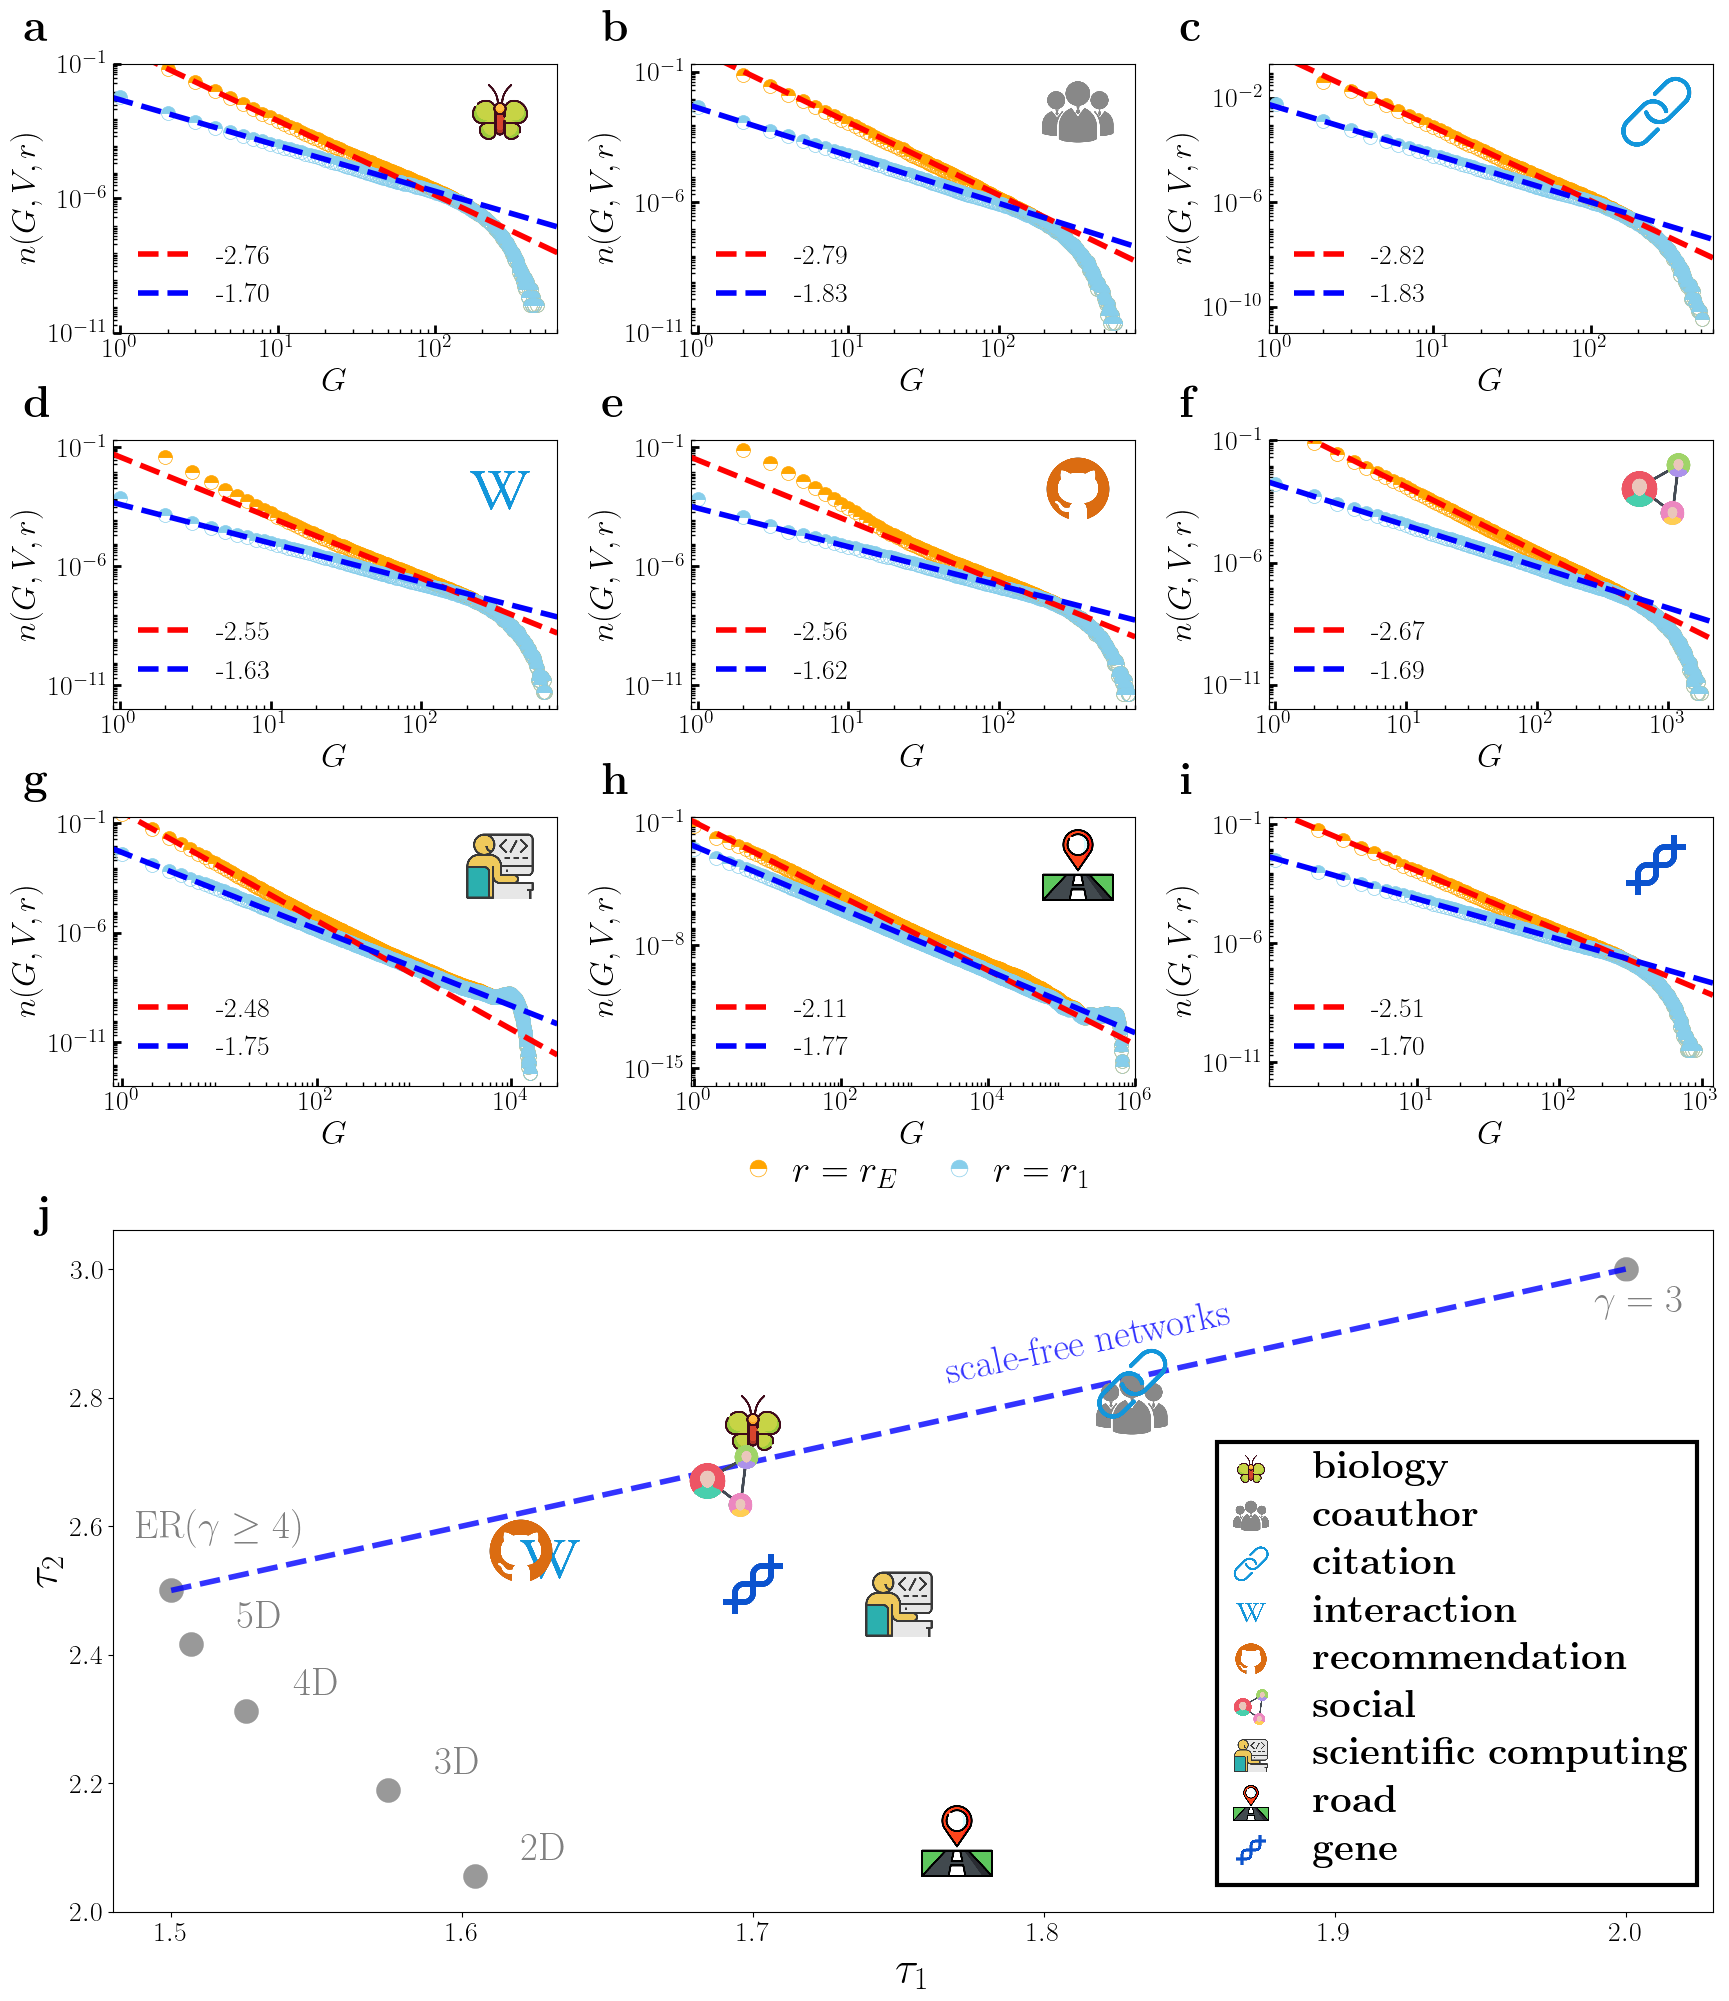

In [1]:
import math
import os
import sys
from dataclasses import dataclass
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
from matplotlib.ticker import LogLocator
from adjustText import adjust_text
from matplotlib.colors import Normalize, to_hex
from io import BytesIO
from PIL import Image
import cairosvg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle

@dataclass
class Panel:
    label: str
    name: str
    file_a: str
    file_b: str
    a0: float
    y0: float
    a1: float
    y1: float
    xrange: Tuple[float, float]
    yrange: Tuple[float, float]
    xticks: Tuple[float, ...]
    yticks: Tuple[float, ...]
    out: str


PANELS = [
    Panel(
        label='a',
        name="biology",
        file_a="ns.HisDc1_F106",
        file_b="ns1.HisDc1_F106",
        a0=0.440,
        y0=-2.76,
        a1=0.00456,
        y1=-1.70,
        xrange=(9e-1, 6e2),
        yrange=(1e-11, 1e-1),
        xticks=(1e0, 1e1, 1e2),
        yticks=(1e-1, 1e-6, 1e-11),
        out="nGa.pdf",
    ),
    Panel(
        label='b',
        name="coauthor",
        file_a="ns.HisDc1_F125",
        file_b="ns1.HisDc1_F125",
        a0=0.707,
        y0=-2.79,
        a1=0.00411,
        y1=-1.83,
        xrange=(9e-1, 8e2),
        yrange=(1e-11, 2e-1),
        xticks=(1e0, 1e1, 1e2),
        yticks=(1e-1,  1e-6, 1e-11),
        out="nGc.pdf",
    ),
    Panel(
        label='c',
        name="citation",
        file_a="ns.HisDc1_F108",
        file_b="ns1.HisDc1_F108",
        a0=0.501,
        y0=-2.82,
        a1=0.00457,
        y1=-1.83,
        xrange=(9e-1, 6e2),
        yrange=(1e-11, 2e-1),
        xticks=(1e0, 1e1, 1e2),
        yticks=(1e-2, 1e-6, 1e-10),
        out="nGb.pdf",
    ),
    Panel(
        label='d',
        name="interaction",
        file_a="ns.HisDc1_F142",
        file_b="ns1.HisDc1_F142",
        a0=0.04,
        y0=-2.55,
        a1=0.000405,
        y1=-1.63,
        xrange=(9e-1, 8e2),
        yrange=(1e-12, 2e-1),
        xticks=(1e0, 1e1, 1e2),
        yticks=(1e-1, 1e-6, 1e-11),
        out="nGd.pdf",
    ),
    Panel(
        label='e',
        name="recommendation",
        file_a="ns.HisDc1_F149",
        file_b="ns1.HisDc1_F149",
        a0=0.0296,
        y0=-2.56,
        a1=0.00028,
        y1=-1.62,
        xrange=(9e-1, 8e2),
        yrange=(1e-12, 2e-1),
        xticks=(1e0, 1e1, 1e2),
        yticks=(1e-1, 1e-6, 1e-11),
        out="nGe.pdf",
    ),
    Panel(
        label='f',
        name="social",
        file_a="ns.HisDc1_F157",
        file_b="ns1.HisDc1_F157",
        a0=0.594,
        y0=-2.67,
        a1=0.00163,
        y1=-1.69,
        xrange=(9e-1, 2.2e3),
        yrange=(1e-12, 1e-1),
        xticks=(1e0, 1e1, 1e2, 1e3),
        yticks=(1e-1, 1e-6, 1e-11),
        out="nGf.pdf",
    ),
    Panel(
        label='g',
        name="scientific computing",
        file_a="ns.HisDc1_F198",
        file_b="ns1.HisDc1_F198",
        a0=0.323,
        y0=-2.48,
        a1=0.0046,
        y1=-1.75,
        xrange=(8e-1, 3e4),
        yrange=(1e-13, 2e-1),
        xticks=(1e0, 1e2, 1e4),
        yticks=(1e-1, 1e-6, 1e-11),
        out="nGg.pdf",
    ),
    Panel(
        label='h',
        name="road",
        file_a="ns.HisDc1_F202",
        file_b="ns1.HisDc1_F202",
        a0=0.1005,
        y0=-2.11,
        a1=0.00428,
        y1=-1.77,
        xrange=(9e-1, 1e6),
        yrange=(1e-16, 2e-1),
        xticks=(1e0, 1e2, 1e4, 1e6),
        yticks=(1e-1, 1e-8, 1e-15),
        out="nGh.pdf",
    ),
    Panel(
        label='i',
        name="gene",
        file_a="ns.HisDc1_F257",
        file_b="ns1.HisDc1_F257",
        a0=0.340,
        y0=-2.51,
        a1=0.00353,
        y1=-1.70,
        xrange=(9e-1, 1.2e3),
        yrange=(1e-12, 2e-1),
        xticks=(1e1, 1e2, 1e3),
        yticks=(1e-1, 1e-6, 1e-11),
        out="nGi.pdf",
    ),
]

def setup_matplotlib_safe():
    """Setup matplotlib with minimal safe configuration."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['text.usetex'] = True
    plt.rcParams.update({'font.size': 24})
    plt.rcParams['axes.labelsize'] = 24
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 20

    global ColorArr 
    global MarkerArr
    global MarSizArr
    global LabelArr
    ColorArr  =['orange', 'skyblue']
    MarkerArr =['o', 'o']
    MarSizArr =[ 10, 10]
    LabelArr = ["$r=r_E$", "$r=r_1$"]

    return 

def read_two_cols(fname, skiprows=1):
    data = np.loadtxt(fname, usecols=(1,3), ndmin=2, skiprows=skiprows)
    x = data[:,0]
    y = data[:,1]
    return x,y

def plot_panel(panel, data_dir, ax):
    afile = os.path.join(data_dir, panel.file_a)
    bfile = os.path.join(data_dir, panel.file_b)

    xa, ya = read_two_cols(afile)
    xb, yb = read_two_cols(bfile) 

    ax.set_xscale("log") 
    ax.set_yscale("log") 
    ax.set_xlim(panel.xrange) 
    ax.set_ylim(panel.yrange)

    ax.plot(xa, ya, color=ColorArr[0], marker=MarkerArr[0], markersize=MarSizArr[0], 
            markerfacecolor=ColorArr[0], fillstyle='top', markeredgewidth=0.5, 
            markeredgecolor='orange', linestyle='', label=f'_nolengend_')
    ax.plot(xb, yb, color=ColorArr[1], marker=MarkerArr[1], markersize=MarSizArr[1], 
            markerfacecolor=ColorArr[1], fillstyle='top', markeredgewidth=0.5, 
            markeredgecolor=ColorArr[1], linestyle='', label=f'_nolengend_')

    # plot model lines
    xline = np.logspace(math.log10(panel.xrange[0]), math.log10(panel.xrange[1]), 150)
    yline0 = panel.a0 * xline ** panel.y0
    yline1 = panel.a1 * xline ** panel.y1
    ax.plot(xline, yline0, linestyle='--', linewidth=4.0, color='red', label=f"{panel.y0:+.2f}")
    ax.plot(xline, yline1, linestyle='--', linewidth=4.0, color='blue', label=f"{panel.y1:+.2f}")

    # ticks and format as 10^{L}
    ax.set_xticks(panel.xticks)
    ax.set_yticks(panel.yticks)
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1, numticks=20))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1, numticks=20))
    ax.tick_params(axis='x', which='major', direction='in', width=2, length=6, colors='black', labelsize=20)
    ax.tick_params(axis='y', which='major', direction='in', width=2, length=6, colors='black', labelsize=20)
    ax.tick_params(axis='x', which='minor', direction='in', width=1, length=3, colors='black')
    ax.tick_params(axis='y', which='minor', direction='in', width=1, length=3, colors='black')

    ax.set_xlabel("$G$", fontsize=24)
    ax.set_ylabel("$n(G,V,r)$", fontsize=24)
#    ax.set_title(panel.name, y=0.87, fontsize=20)
    ax.text(-0.20, 1.20,r'$\mathbf{' + panel.label +'}$', transform=ax.transAxes, fontsize=32, 
            fontweight='bold', verticalalignment='top', horizontalalignment='left')
    ax.legend(loc='lower left', frameon=False, fancybox=True, fontsize=20)

    title1 = panel.name 
    f1 = title1 + ".svg" 
    CurDir = os.getcwd()
    svg_path1 = os.path.join(CurDir, 'svgicon')
    svg_path = os.path.join(svg_path1, f1)
    png = cairosvg.svg2png(url=svg_path, output_width=256, output_height=256)
    img = Image.open(BytesIO(png)).convert('RGBA')
    arr = np.array(img)
    ab = AnnotationBbox(OffsetImage(img, zoom=0.20), (0.95, 0.95), xycoords="axes fraction", box_alignment=(1,1), frameon=False)
    ax.add_artist(ab)

    
    return 

def plot_scatter_plot(ax):

    data1 = {
        "type": ["2D", "3D", "4D", "5D", "ER($\\gamma \\ge 4$)", "$\\gamma=3$"],
        "t1": [1.6044, 1.5746, 1.5258, 1.5067, 1.5, 2.0],
        "t2": [2.0549, 2.1899, 2.3124, 2.4171, 2.5, 3.0]
    }

    # 添加虚线 t2 = t1 + 1 (1.5 < t1 < 2.0)
    x_line = np.linspace(1.5, 2.0, 50)
    y_line = x_line + 1
    mid_point = len(x_line)//2
    ax.plot(x_line, y_line, '--', color="blue", linewidth=4.0, alpha=0.8)
    ax.text(x_line[mid_point+6], y_line[mid_point+6] + 0.04,
            "scale-free networks",
            rotation=12,
            rotation_mode='anchor',
            ha='center', va='bottom',
            fontsize=28, color="blue",
            alpha=0.8,
            bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.8))

    scatter = ax.scatter(data1["t1"], data1["t2"], c="gray", s=300, alpha=0.8, edgecolors='gray', linewidth=0.3)

    # 添加标签
    texts = []
    for i, txt in enumerate(data1["type"]):

        xdis = data1["t1"][i] + 0.015; ydis= data1["t2"][i] + 0.015

        if txt   == "ER($\\gamma \\ge 4$)":
            xdis = data1["t1"][i] - 0.015; ydis= data1["t2"][i] + 0.065
        if txt == "$\\gamma=3$":
            xdis = data1["t1"][i] + 0.015; ydis= data1["t2"][i] - 0.085
        texts.append(ax.text(xdis,  ydis, txt, fontsize=28, color='gray', weight='bold', 
                bbox=dict( boxstyle='round,pad=0.1', fc=(1,1,1,0.8), ec='none' ) ) )

        # 智能调整标签位置
    adjust_text(texts, expand_points=(1.5, 1.5),
                   expand_text=(1.2, 1.2),
                   force_text=(0.3, 0.3),
                   ensure_inside_axes=True,
                   lim=500)
    data2 = {
        "type": ["biology", "social", "road", "coauthor", "citation",  "interaction", "recommendation", 
                 "scientific computing", "gene"],
        "t1": [1.7, 1.69, 1.77, 1.83, 1.83, 1.63, 1.62, 1.75, 1.7],
        "t2": [2.76, 2.67, 2.11,2.79, 2.82, 2.55, 2.56, 2.48, 2.51]
    }

    # Convert SVG to PNG bytes and load as RGBA numpy array (Cell 2)
    CurDir = os.getcwd()
    svg_path1 = os.path.join(CurDir, 'svgicon')
    FileSvg = os.listdir(svg_path1)
    zm1 = 0.20 
    zm2 = 0.10
    imgx = 0.70
    imgy = 0.65
    ind2 = 0
    OrderedTitle=["biology", "coauthor", "citation", "interaction", "recommendation", "social", "scientific computing", "road", "gene"]
    for title1 in OrderedTitle:
#    for title1 in data2["type"]:
        f1 = title1 + ".svg"
#        title1 = f1.split('.')[0]
        index1 = data2["type"].index(title1) 
        t1 = data2["t1"][index1]
        t2 = data2["t2"][index1]

        svg_path = os.path.join(svg_path1, f1)
        png = cairosvg.svg2png(url=svg_path, output_width=256, output_height=256)
        img = Image.open(BytesIO(png)).convert('RGBA')
        arr = np.array(img)
        ab = AnnotationBbox(OffsetImage(img, zoom=zm1), (t1, t2), frameon=False)
        ax.add_artist(ab)

        img_x = imgx  
        img_y = imgy - 0.07*ind2
        ind2 = ind2 + 1
        imagebox = OffsetImage(arr, zoom=zm2)
        ab = AnnotationBbox(imagebox, (img_x, img_y), xycoords='axes fraction', frameon=False, box_alignment=(0, 0.5))
        ax.add_artist(ab)
        text_x = img_x + 0.05
        if title1.startswith("sci"):
            title1 = "scientific \\ computing"
        ax.text(text_x, img_y, r'$\mathbf{' + title1 +'}$', transform=ax.transAxes, va='center', fontsize=28)

    rect = Rectangle((0.69, 0.04), 0.30, 0.65, transform=ax.transAxes, fill=False, edgecolor="black", linewidth=3 )
    ax.add_patch(rect)

    # 坐标轴设置
    ax.set_xlabel(r"$\tau_1$", fontsize=32)
    ax.set_ylabel(r"$\tau_2$", fontsize=32)
    ax.text(-0.05, 1.05,r'$\mathbf{' + 'j' +'}$', transform=ax.transAxes, fontsize=32, 
            fontweight='bold', verticalalignment='top', horizontalalignment='left')

    # 刻度设置
    ax.tick_params(axis='both', which='major', labelsize=20)

    # 坐标范围
    ax.set_xlim(1.48, 2.03)
    ax.set_ylim(2.0, 3.06)

    return 

# 主程序
Curdir = os.getcwd()
data_dir = os.path.join(Curdir, "NsSel")
setup_matplotlib_safe()

# 创建上下排列的子图 - 高度比3:2
fig = plt.figure(figsize=(20, 24))

# 使用GridSpec创建3:2的高度比例
gs = plt.GridSpec(2, 1, figure=fig, height_ratios=[3, 2], hspace=0.17)  # 减小hspace

# 上部：3x3 子图网格 (占3/5高度)
gs_top = gs[0].subgridspec(3, 3, hspace=0.40, wspace=0.30)
axes_top = []
for i in range(3):
    for j in range(3):
        ax = fig.add_subplot(gs_top[i, j])
        axes_top.append(ax)

# 下部：散点图 (占2/5高度)
ax_bottom = fig.add_subplot(gs[1])

# 绘制上部子图
for k, panel in enumerate(PANELS):
    if k < len(axes_top):
        ax = axes_top[k]
        print(f"plotting {panel.name}")
        plot_panel(panel, data_dir, ax)

# 绘制下部散点图
plot_scatter_plot(ax_bottom)

# 创建图例元素（用于上部子图）
legend_elements = [Line2D([0], [0], marker=MarkerArr[k], color=ColorArr[k], 
                   markerfacecolor=ColorArr[k], markersize=12,
                   fillstyle='top', markeredgewidth=0.5, markeredgecolor=ColorArr[k], 
                   linestyle='None', label=LabelArr[k]) for k in range(2)]

# 将图例放在上部区域的顶部中央，调小距离
fig.legend(handles=legend_elements,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.44),  # 从0.98改为0.99，减小距离
           ncol=2,
           fontsize=28,
           frameon=False,
           fancybox=True,
           shadow=False,
           handletextpad=0.3,
           columnspacing=1.0,
           handlelength=1.2)

# 调整左边空白
plt.subplots_adjust(left=0.10)  # 减小左边空白

#plt.tight_layout()
plt.savefig("Fig4.pdf", bbox_inches='tight')
plt.show()